In [19]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [20]:
# Step 2: Load Dataset

df = pd.read_csv("AAPL.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10468 entries, 0 to 10467
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10468 non-null  object 
 1   Open       10468 non-null  float64
 2   High       10468 non-null  float64
 3   Low        10468 non-null  float64
 4   Close      10468 non-null  float64
 5   Adj Close  10468 non-null  float64
 6   Volume     10468 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 572.6+ KB
None
Date   

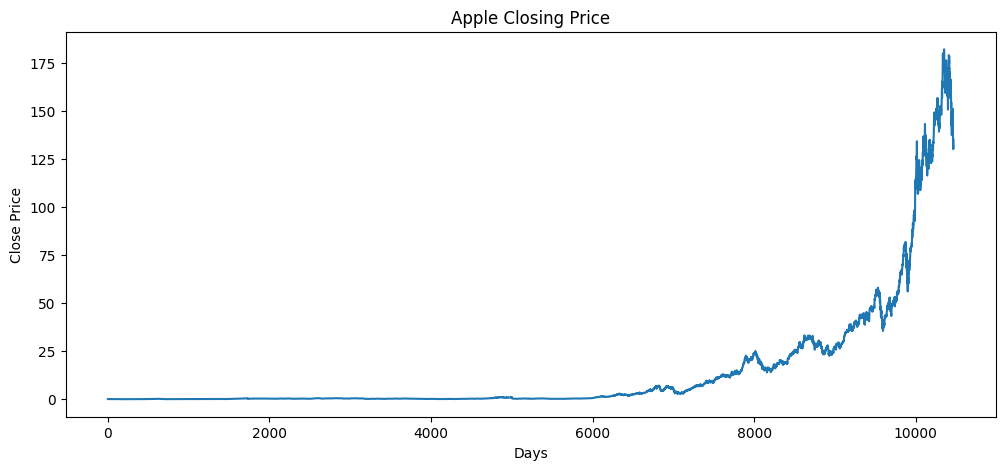

In [21]:
# Step 3: Select Required Column

data = df[['Close']]

plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("Apple Closing Price")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.show()

In [22]:
# Step 4: Normalize Data

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [23]:
# Step 5: Create Sequences

time_step = 60

X = []
y = []

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i,0])
    y.append(scaled_data[i,0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0],X.shape[1],1)

print(X.shape)
print(y.shape)

(10408, 60, 1)
(10408,)


In [24]:
# Step 6: Train Test Split

split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
# Step 7: Build Simple RNN

model = Sequential()

model.add(SimpleRNN(
    units=50,
    activation='tanh',
    input_shape=(X_train.shape[1],1)
))

model.add(Dense(1))

c:\Users\ckash\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
# Step 8: Compile Model

model.compile(
    optimizer='adam',
    loss='mse'
)

In [27]:
# Step 9: Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [28]:
# Step 10: Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test,y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 7.1568e-05 - val_loss: 0.0358
Epoch 2/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.5132e-06 - val_loss: 0.0149
Epoch 3/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.6296e-06 - val_loss: 0.0105
Epoch 4/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.2234e-06 - val_loss: 0.0070
Epoch 5/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.1843e-06 - val_loss: 0.0048
Epoch 6/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.0569e-06 - val_loss: 0.0047
Epoch 7/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 9.4811e-07 - val_loss: 0.0027
Epoch 8/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.6111e-07 - val_loss: 0.0023
Epoch 9/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 8.1901e-07 - val_loss: 0.0021
Epoch 10/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 7.9217e-07 - val_loss: 0.0018
Epoch 11/50
261/261 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 8.7798e-07 - val_loss: 0.0016
Epoch 1

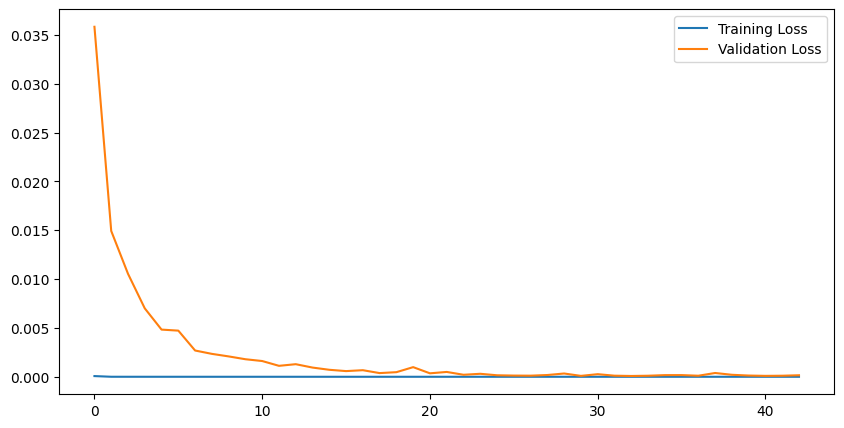

In [29]:
# Step 11: Plot Loss

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.legend()
plt.show()

In [30]:
# Step 12: Prediction

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y_test.reshape(-1,1))

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [31]:
# Step 13: Evaluation

rmse = np.sqrt(mean_squared_error(actual,predictions))
mae = mean_absolute_error(actual,predictions)

print("RMSE :",rmse)
print("MAE :",mae)

RMSE : 1.653431883831373
MAE : 1.0426568783038137


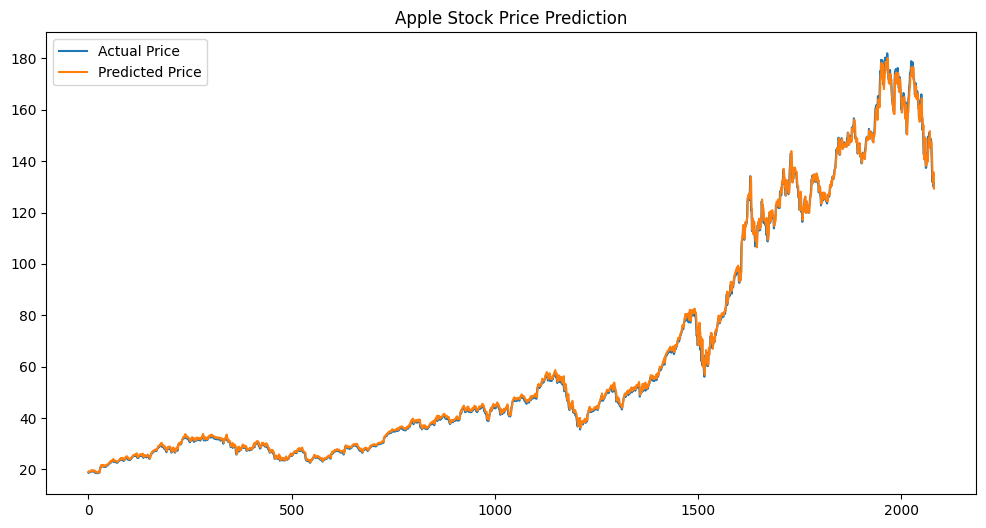

In [32]:
# Step 14: Actual vs Predicted

plt.figure(figsize=(12,6))

plt.plot(actual,label="Actual Price")
plt.plot(predictions,label="Predicted Price")

plt.legend()

plt.title("Apple Stock Price Prediction")

plt.show()

In [33]:
# Step 15: Save Model

model.save("apple_rnn_model.keras")

print("Model Saved Successfully")

Model Saved Successfully


In [34]:
# Step 16: Load Model

from tensorflow.keras.models import load_model

loaded_model = load_model("apple_rnn_model.keras")

In [35]:
# Step 17: Predict Next Closing Price

last_60_days = scaled_data[-60:]

last_60_days = last_60_days.reshape(1,60,1)

next_price = loaded_model.predict(last_60_days)

next_price = scaler.inverse_transform(next_price)

print("Next Predicted Closing Price :",next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
Next Predicted Closing Price : 132.14993
